### Create Figures

# Diagnostics

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

In [2]:
# Base directory
DATA_DIR = Path("../256_diag/cfl1")

csv_files = sorted(DATA_DIR.glob("diagnostics_*.csv"))



print(f"Found {len(csv_files)} file(s):")
for f in csv_files:
    print(" -", f)

Found 8 file(s):
 - ../256_diag/cfl1/diagnostics_FirstOrder_256x256_omp12_2026-03-04_17-20-21.csv
 - ../256_diag/cfl1/diagnostics_FirstOrder_512x512_omp12_2026-03-04_17-56-45.csv
 - ../256_diag/cfl1/diagnostics_TENO5_256x256_omp12_2026-03-04_17-20-21.csv
 - ../256_diag/cfl1/diagnostics_TENO5_512x512_omp12_2026-03-04_17-56-45.csv
 - ../256_diag/cfl1/diagnostics_WENO3_256x256_omp12_2026-03-04_17-20-21.csv
 - ../256_diag/cfl1/diagnostics_WENO3_512x512_omp12_2026-03-04_17-56-45.csv
 - ../256_diag/cfl1/diagnostics_WENO5_256x256_omp12_2026-03-04_17-20-21.csv
 - ../256_diag/cfl1/diagnostics_WENO5_512x512_omp12_2026-03-04_17-56-45.csv


In [3]:
def parse_filename_metadata(filename):
    """
    Expected examples:
      diagnostics_FirstOrder_512x512_omp12_2026-03-04_17-56-45.csv
      diagnostics_WENO3_512x512_omp12.csv
    """
    stem = Path(filename).stem

    # Remove leading "diagnostics_"
    if stem.startswith("diagnostics_"):
        stem = stem[len("diagnostics_"):]

    # Find resolution and omp anywhere in the string
    m = re.search(r"(?P<scheme>.+?)_(?P<nx>\d+)x(?P<ny>\d+)_omp(?P<omp>\d+)", stem)

    if m is None:
        print(f"WARNING: could not parse metadata from filename: {filename}")
        return {
            "scheme": "Unknown",
            "nx": np.nan,
            "ny": np.nan,
            "omp": np.nan,
            "filename": Path(filename).name,
        }

    return {
        "scheme": m.group("scheme"),
        "nx": int(m.group("nx")),
        "ny": int(m.group("ny")),
        "omp": int(m.group("omp")),
        "filename": Path(filename).name,
    }

In [4]:
def load_diagnostics(csv_path):
    df = pd.read_csv(csv_path)
    meta = parse_filename_metadata(csv_path.name)

    for k, v in meta.items():
        df[k] = v

    # Optional derived columns
    if "t" in df.columns:
        df["sim_us"] = df["t"] * 1e6

    if "wall_total_s" in df.columns:
        df["wall_total_min"] = df["wall_total_s"] / 60.0

    if "wall_step_s" in df.columns and "dt" in df.columns:
        df["cost_per_physical_second"] = df["wall_step_s"] / df["dt"]

    return df

dfs = [load_diagnostics(f) for f in csv_files]
df_all = pd.concat(dfs, ignore_index=True)

print(df_all[["filename", "scheme", "nx", "ny", "omp"]].drop_duplicates().to_string(index=False))

print(df_all.shape)
df_all.head()

                                                    filename     scheme  nx  ny  omp
diagnostics_FirstOrder_256x256_omp12_2026-03-04_17-20-21.csv FirstOrder 256 256   12
diagnostics_FirstOrder_512x512_omp12_2026-03-04_17-56-45.csv FirstOrder 512 512   12
     diagnostics_TENO5_256x256_omp12_2026-03-04_17-20-21.csv      TENO5 256 256   12
     diagnostics_TENO5_512x512_omp12_2026-03-04_17-56-45.csv      TENO5 512 512   12
     diagnostics_WENO3_256x256_omp12_2026-03-04_17-20-21.csv      WENO3 256 256   12
     diagnostics_WENO3_512x512_omp12_2026-03-04_17-56-45.csv      WENO3 512 512   12
     diagnostics_WENO5_256x256_omp12_2026-03-04_17-20-21.csv      WENO5 256 256   12
     diagnostics_WENO5_512x512_omp12_2026-03-04_17-56-45.csv      WENO5 512 512   12
(1055, 23)


,step,t,dt,wall_step_s,wall_total_s,shock_ok,shock_y,shock_x,dpdx_max,p_min,p_max,thickness_cells,thickness_m,TV_rho,smooth_lap_p,scheme,nx,ny,omp,filename,sim_us,wall_total_min,cost_per_physical_second
0,100,6.627981e-08,6.880778e-10,0.009924,1.606318,0,0.00249,0.0,0.0,100000.0,100000.0,0,0.0,47.955581,0.021180,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.066280,0.026772,1.442224e+07
1,200,1.402596e-07,8.023072e-10,0.010121,2.979373,0,0.00249,0.0,0.0,100000.0,100000.0,0,0.0,71.727158,0.002305,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.140260,0.049656,1.261493e+07
2,300,2.287312e-07,9.692776e-10,0.010731,4.576340,0,0.00249,0.0,0.0,100000.0,100000.0,0,0.0,97.944563,0.000377,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.228731,0.076272,1.107096e+07
3,400,3.344367e-07,1.141998e-09,0.013068,6.959429,0,0.00249,0.0,0.0,100000.0,100000.0,0,0.0,122.204660,0.000183,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.334437,0.115990,1.144332e+07
4,500,4.570641e-07,1.307388e-09,0.011332,9.289332,0,0.00249,0.0,0.0,100000.0,100000.0,0,0.0,142.388098,0.000214,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.457064,0.154822,8.667869e+06


In [5]:
print("Columns:")
print(df_all.columns.tolist())

print("\nUnique schemes:")
print(df_all["scheme"].dropna().unique())

print("\nUnique nx:")
print(sorted(df_all["nx"].dropna().unique()))

print("\nUnique ny:")
print(sorted(df_all["ny"].dropna().unique()))

print("\nUnique omp:")
print(sorted(df_all["omp"].dropna().unique()))

print("\nLoaded files:")
print(df_all[["filename", "scheme", "nx", "ny", "omp"]].drop_duplicates().to_string(index=False))

Columns:
['step', 't', 'dt', 'wall_step_s', 'wall_total_s', 'shock_ok', 'shock_y', 'shock_x', 'dpdx_max', 'p_min', 'p_max', 'thickness_cells', 'thickness_m', 'TV_rho', 'smooth_lap_p', 'scheme', 'nx', 'ny', 'omp', 'filename', 'sim_us', 'wall_total_min', 'cost_per_physical_second']

Unique schemes:
['FirstOrder' 'TENO5' 'WENO3' 'WENO5']

Unique nx:
[256, 512]

Unique ny:
[256, 512]

Unique omp:
[12]

Loaded files:
                                                    filename     scheme  nx  ny  omp
diagnostics_FirstOrder_256x256_omp12_2026-03-04_17-20-21.csv FirstOrder 256 256   12
diagnostics_FirstOrder_512x512_omp12_2026-03-04_17-56-45.csv FirstOrder 512 512   12
     diagnostics_TENO5_256x256_omp12_2026-03-04_17-20-21.csv      TENO5 256 256   12
     diagnostics_TENO5_512x512_omp12_2026-03-04_17-56-45.csv      TENO5 512 512   12
     diagnostics_WENO3_256x256_omp12_2026-03-04_17-20-21.csv      WENO3 256 256   12
     diagnostics_WENO3_512x512_omp12_2026-03-04_17-56-45.csv      WENO3 51

In [6]:
summary_loaded = (
    df_all[["scheme", "nx", "ny", "omp", "filename"]]
    .drop_duplicates()
    .sort_values(["scheme", "nx", "ny", "omp"])
    .reset_index(drop=True)
)

summary_loaded

,scheme,nx,ny,omp,filename
0,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...
1,FirstOrder,512,512,12,diagnostics_FirstOrder_512x512_omp12_2026-03-0...
2,TENO5,256,256,12,diagnostics_TENO5_256x256_omp12_2026-03-04_17-...
3,TENO5,512,512,12,diagnostics_TENO5_512x512_omp12_2026-03-04_17-...
4,WENO3,256,256,12,diagnostics_WENO3_256x256_omp12_2026-03-04_17-...
5,WENO3,512,512,12,diagnostics_WENO3_512x512_omp12_2026-03-04_17-...
6,WENO5,256,256,12,diagnostics_WENO5_256x256_omp12_2026-03-04_17-...
7,WENO5,512,512,12,diagnostics_WENO5_512x512_omp12_2026-03-04_17-...


In [7]:
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:")
print(numeric_cols)

print("\nMissing values per column:")
display(df_all.isna().sum())

print("\nRows with shock_ok == 0:")
if "shock_ok" in df_all.columns:
    display(df_all[df_all["shock_ok"] == 0].head(20))

Numeric columns:
['step', 't', 'dt', 'wall_step_s', 'wall_total_s', 'shock_ok', 'shock_y', 'shock_x', 'dpdx_max', 'p_min', 'p_max', 'thickness_cells', 'thickness_m', 'TV_rho', 'smooth_lap_p', 'nx', 'ny', 'omp', 'sim_us', 'wall_total_min', 'cost_per_physical_second']

Missing values per column:


step                        0
t                           0
dt                          0
wall_step_s                 0
wall_total_s                0
shock_ok                    0
shock_y                     0
shock_x                     0
dpdx_max                    0
p_min                       0
p_max                       0
thickness_cells             0
thickness_m                 0
TV_rho                      0
smooth_lap_p                0
scheme                      0
nx                          0
ny                          0
omp                         0
filename                    0
sim_us                      0
wall_total_min              0
cost_per_physical_second    0
dtype: int64


Rows with shock_ok == 0:


,step,t,dt,wall_step_s,wall_total_s,shock_ok,shock_y,shock_x,dpdx_max,p_min,p_max,thickness_cells,thickness_m,TV_rho,smooth_lap_p,scheme,nx,ny,omp,filename,sim_us,wall_total_min,cost_per_physical_second
0,100,6.627981e-08,6.880778e-10,0.009924,1.606318,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,47.955581,0.021180,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.066280,0.026772,1.442224e+07
1,200,1.402596e-07,8.023072e-10,0.010121,2.979373,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,71.727158,0.002305,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.140260,0.049656,1.261493e+07
2,300,2.287312e-07,9.692776e-10,0.010731,4.576340,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,97.944563,0.000377,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.228731,0.076272,1.107096e+07
3,400,3.344367e-07,1.141998e-09,0.013068,6.959429,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,122.204660,0.000183,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.334437,0.115990,1.144332e+07
4,500,4.570641e-07,1.307388e-09,0.011332,9.289332,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,142.388098,0.000214,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.457064,0.154822,8.667869e+06
5,600,5.956426e-07,1.460980e-09,0.042231,11.677095,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,158.344393,0.000243,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.595643,0.194618,2.890600e+07
6,700,7.489816e-07,1.602298e-09,0.010198,14.044826,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,170.245064,0.000352,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.748982,0.234080,6.364620e+06
7,800,9.158396e-07,1.731361e-09,0.011497,16.431508,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,178.812042,0.000357,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,0.915840,0.273858,6.640356e+06
8,900,1.095019e-06,1.849022e-09,0.010352,18.779445,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,184.922838,0.000294,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,1.095019,0.312991,5.598868e+06
9,1000,1.285415e-06,1.956392e-09,0.010289,21.167542,0,0.002490,0.0,0.0,100000.0,100000.0,0,0.0,189.228767,0.000346,FirstOrder,256,256,12,diagnostics_FirstOrder_256x256_omp12_2026-03-0...,1.285415,0.352792,5.259067e+06


In [8]:
def plot_run(df, scheme=None, nx=None, ny=None, omp=None):
    subset = df.copy()

    print("Available combinations:")
    print(
        subset[["scheme", "nx", "ny", "omp"]]
        .drop_duplicates()
        .sort_values(["scheme", "nx", "ny", "omp"])
        .to_string(index=False)
    )

    if scheme is not None:
        subset = subset[subset["scheme"] == scheme]
        print(f"\nAfter scheme filter ({scheme}): {len(subset)} rows")

    if nx is not None:
        subset = subset[subset["nx"] == nx]
        print(f"After nx filter ({nx}): {len(subset)} rows")

    if ny is not None:
        subset = subset[subset["ny"] == ny]
        print(f"After ny filter ({ny}): {len(subset)} rows")

    if omp is not None:
        subset = subset[subset["omp"] == omp]
        print(f"After omp filter ({omp}): {len(subset)} rows")

    if subset.empty:
        print("\nNo matching data found.")
        return

    subset = subset.sort_values("t")

    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.ravel()

    plot_cols = [
        ("shock_x", "Shock position vs time", "shock_x [m]"),
        ("thickness_cells", "Shock thickness vs time", "thickness_cells"),
        ("TV_rho", "TV(rho) vs time", "TV_rho"),
        ("smooth_lap_p", "Smooth-region metric vs time", "smooth_lap_p"),
        ("wall_step_s", "Wall time per step vs time", "wall_step_s [s]"),
        ("dt", "dt vs time", "dt [s]")
    ]

    for ax, (col, title, ylabel) in zip(axes, plot_cols):
        if col in subset.columns:
            ax.plot(subset["t"], subset[col])
            ax.set_title(title)
            ax.set_xlabel("t [s]")
            ax.set_ylabel(ylabel)
        else:
            ax.text(0.5, 0.5, f"Missing column:\n{col}", ha="center", va="center")
            ax.set_title(title)

    title = f"{subset['scheme'].iloc[0]} | {subset['nx'].iloc[0]}x{subset['ny'].iloc[0]} | omp{subset['omp'].iloc[0]}"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

Available combinations:
    scheme  nx  ny  omp
FirstOrder 256 256   12
FirstOrder 512 512   12
     TENO5 256 256   12
     TENO5 512 512   12
     WENO3 256 256   12
     WENO3 512 512   12
     WENO5 256 256   12
     WENO5 512 512   12

After scheme filter (FirstOrder): 146 rows
After nx filter (512): 106 rows
After ny filter (512): 106 rows
After omp filter (12): 106 rows


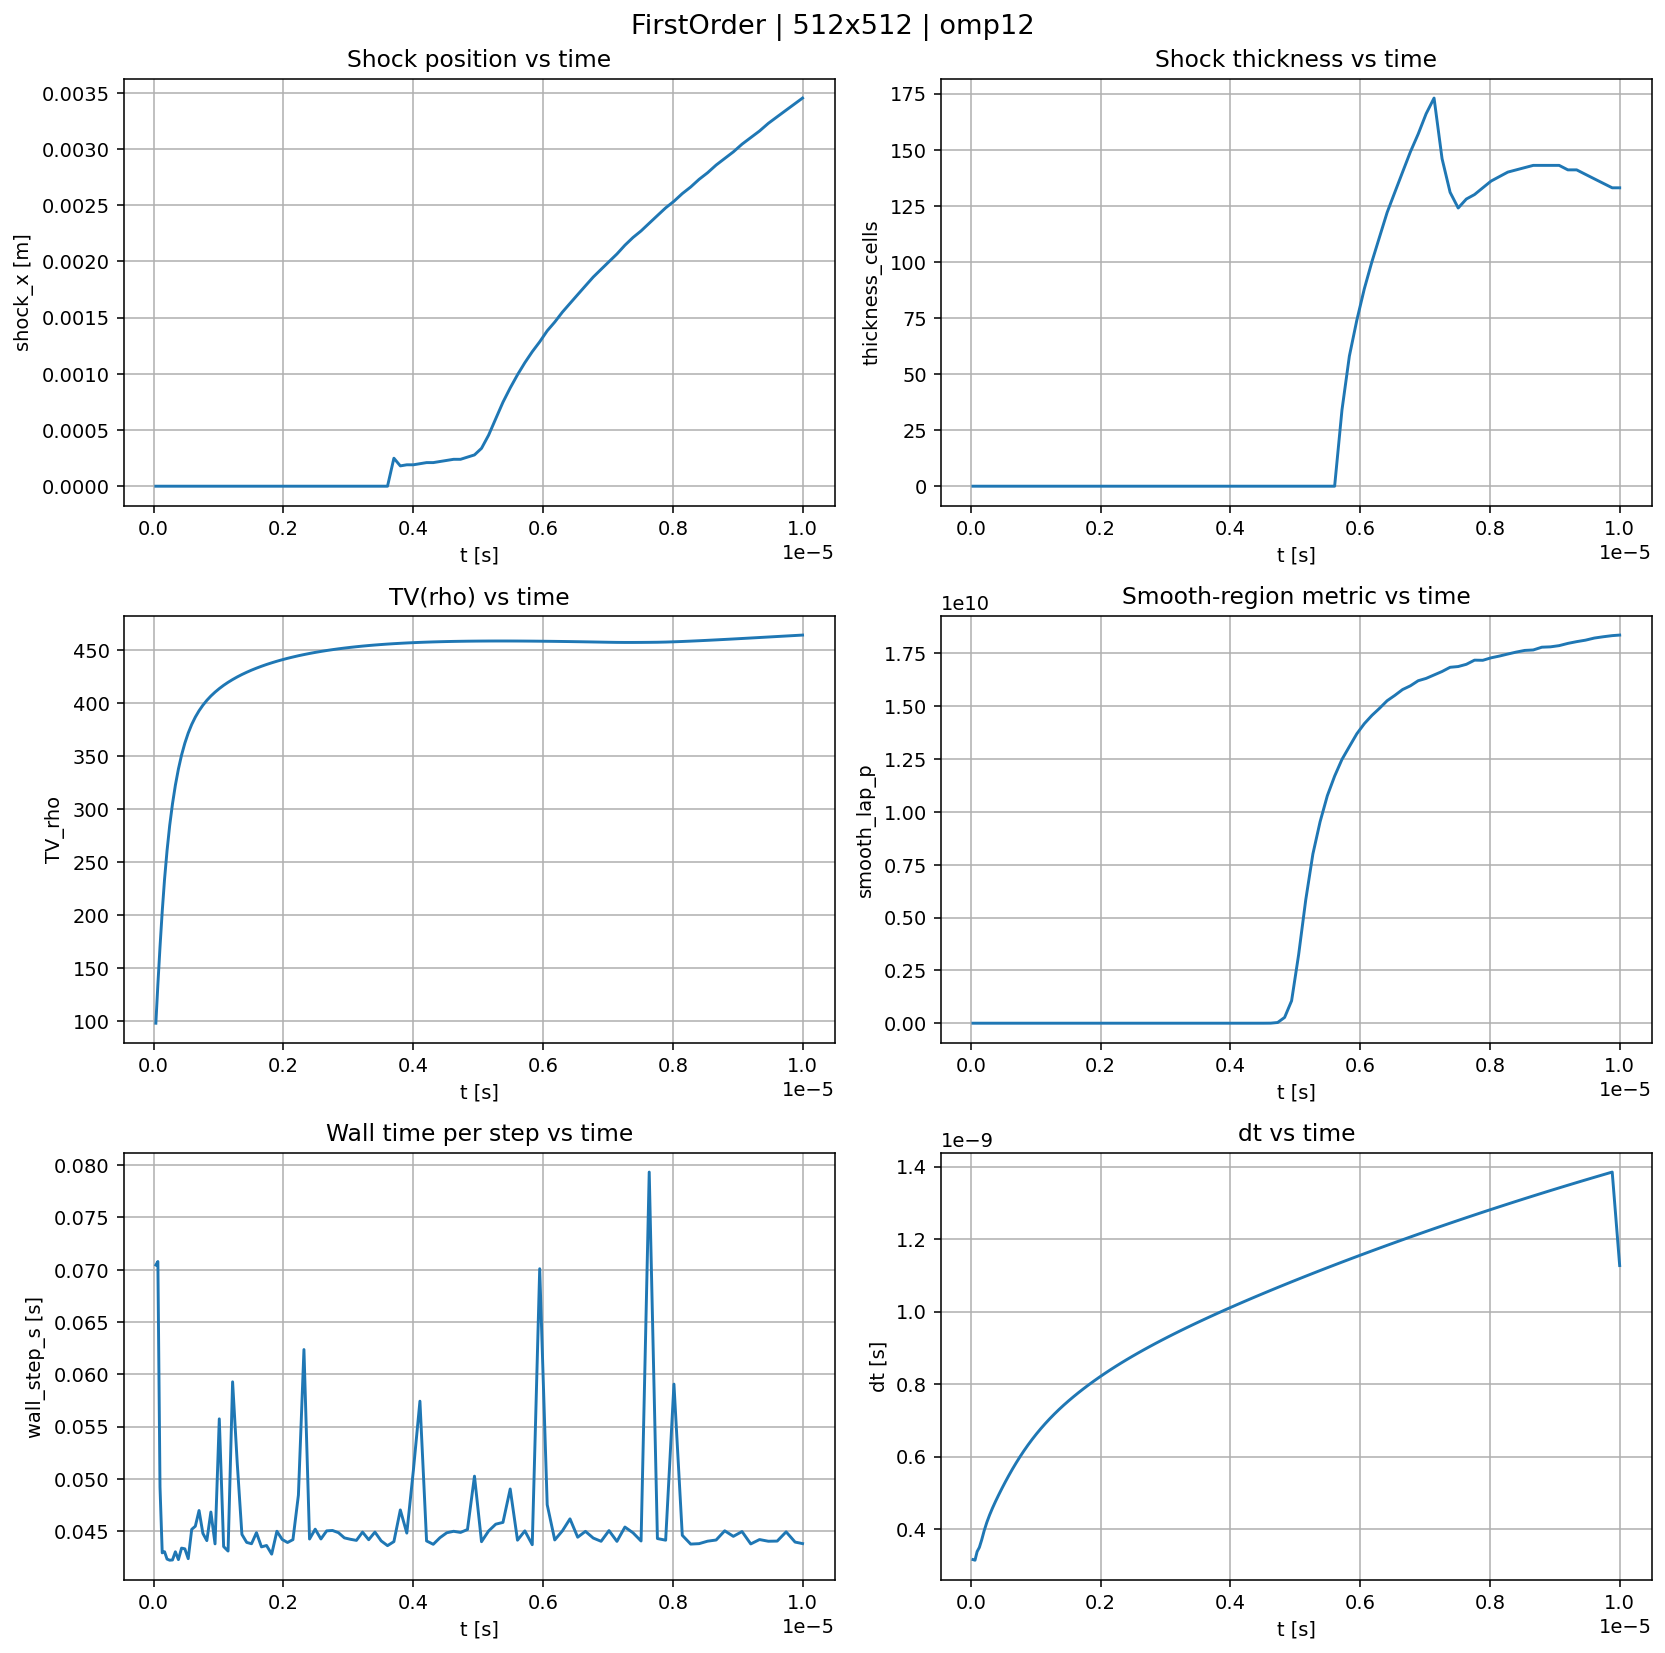

In [9]:
plot_run(df_all, scheme="FirstOrder", nx=512, ny=512, omp=12)

In [22]:
def compare_metric(df, metric, nx=None, ny=None, omp=None):
    subset = df.copy()

    if nx is not None:
        subset = subset[subset["nx"] == nx]
    if ny is not None:
        subset = subset[subset["ny"] == ny]
    if omp is not None:
        subset = subset[subset["omp"] == omp]

    if subset.empty:
        print("No matching data found.")
        return

    plt.figure(figsize=(10, 5))

    for scheme, g in subset.groupby("scheme"):
        g = g.sort_values("t")
        plt.plot(g["t"], g[metric], label=scheme)

    plt.xlabel("Simulation Time [s]")
    plt.ylabel("Step Time [s]") #metric)
    #plt.title(f"{metric} comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

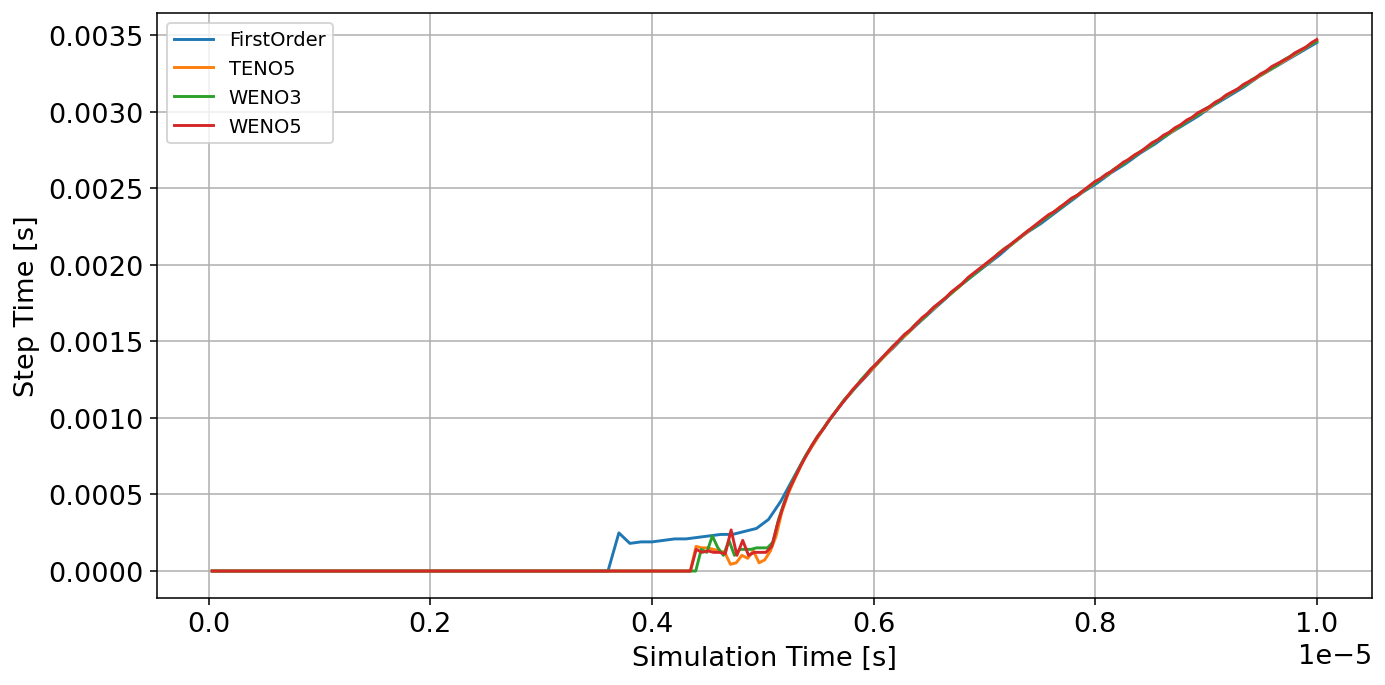

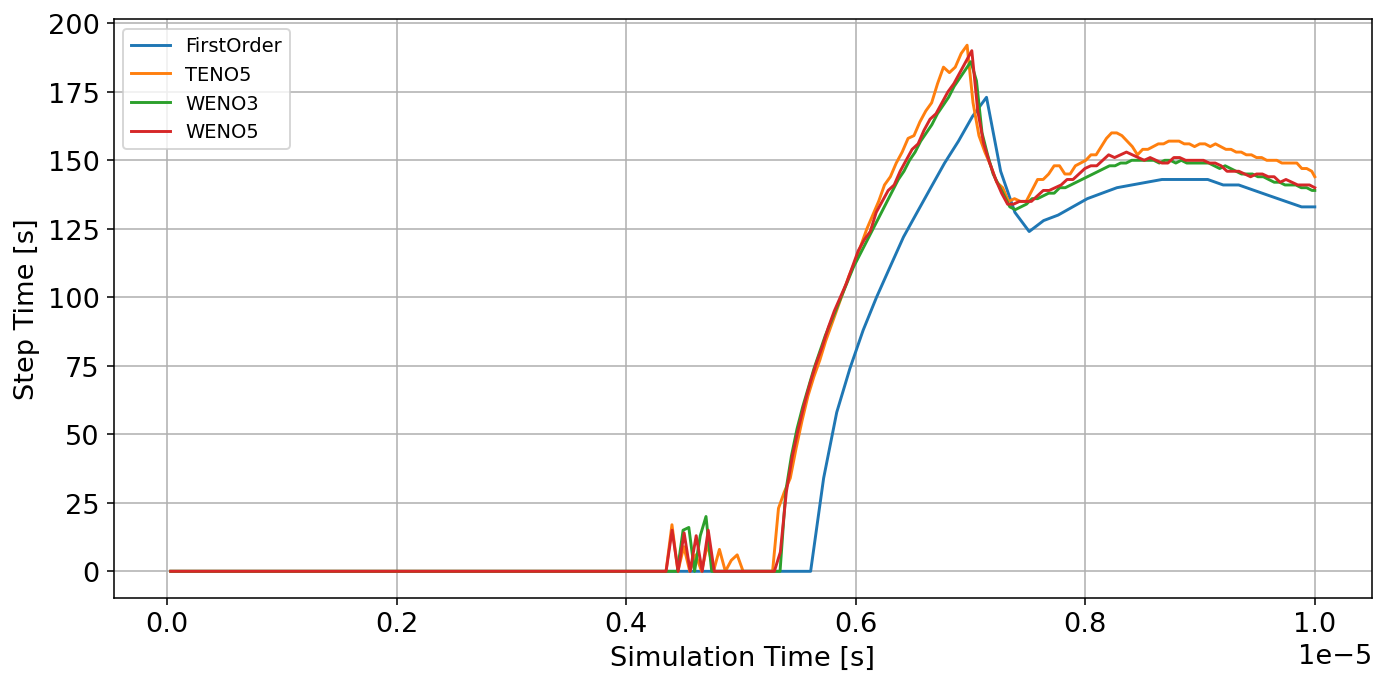

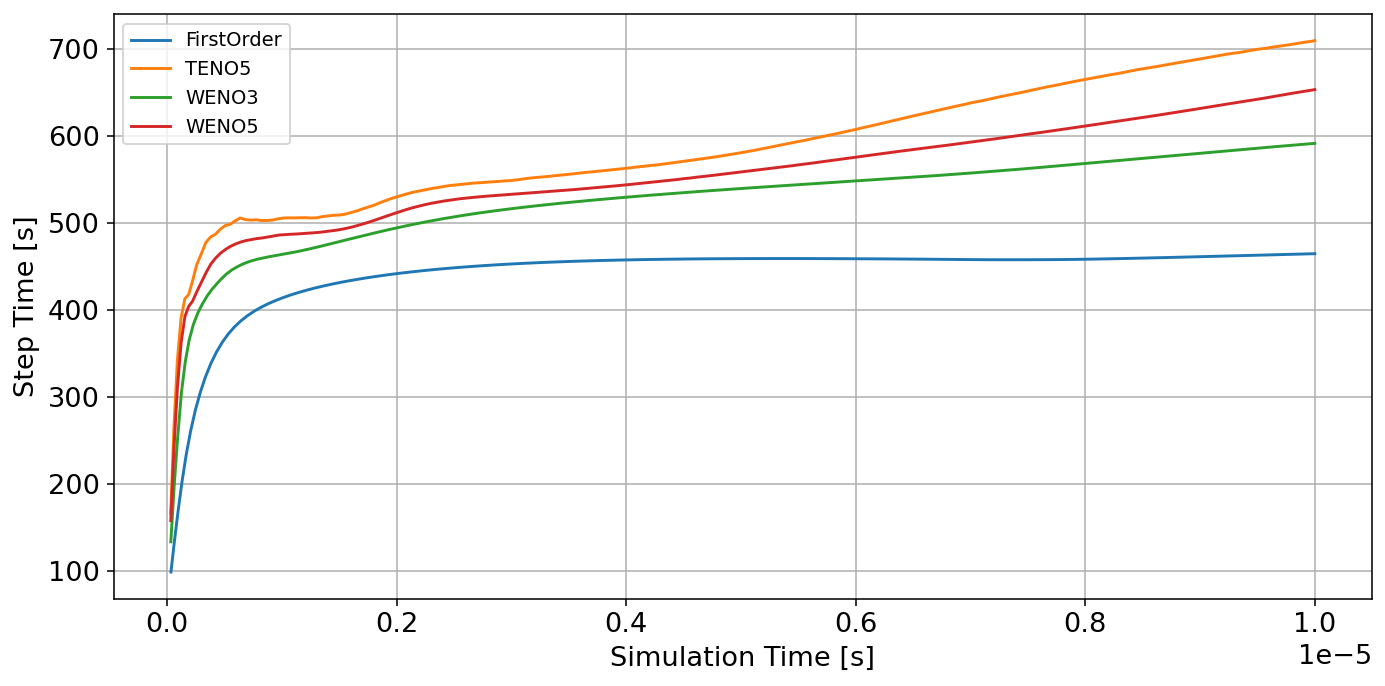

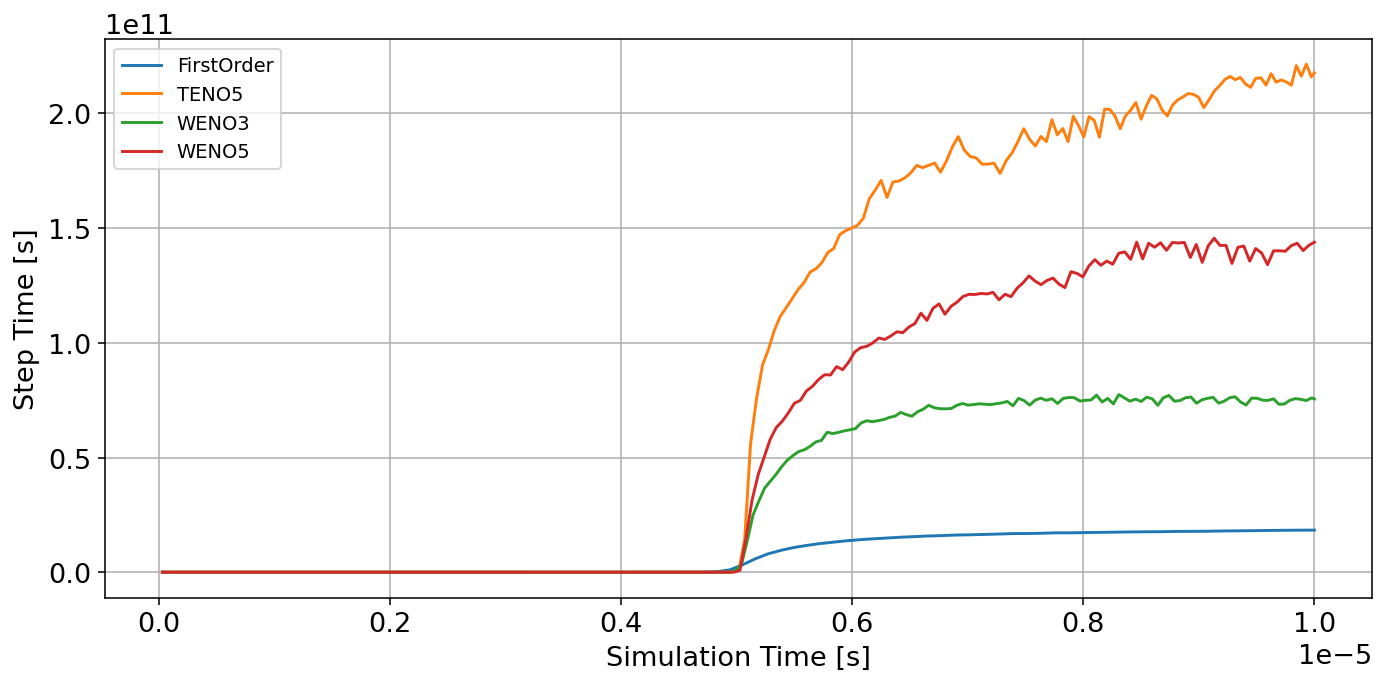

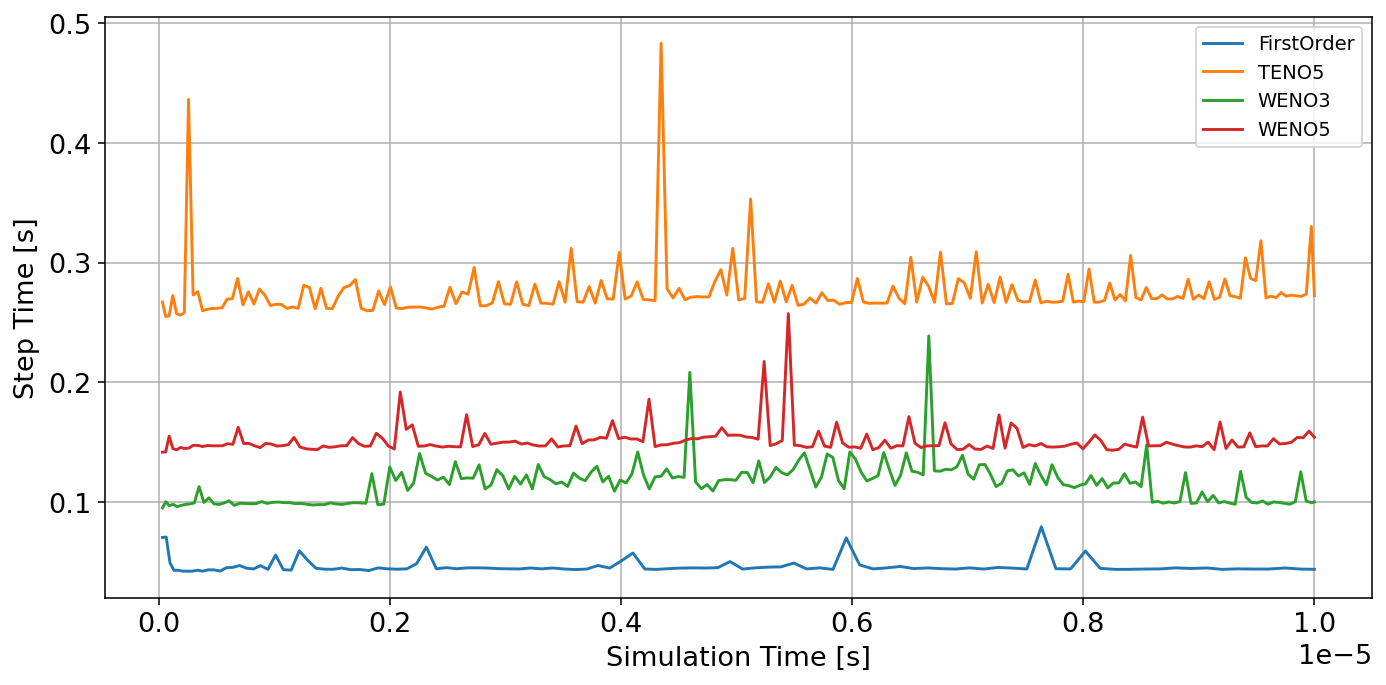

In [23]:
# Set specific sizes for axis labels and tick labels
plt.rcParams['axes.labelsize'] = 14   # Fontsize of the x and y axis labels
plt.rcParams['xtick.labelsize'] = 14  # Fontsize of the x tick labels
plt.rcParams['ytick.labelsize'] = 14  # Fontsize of the y tick labels


compare_metric(df_all, "shock_x", nx=512, ny=512, omp=12)
compare_metric(df_all, "thickness_cells", nx=512, ny=512, omp=12)
compare_metric(df_all, "TV_rho", nx=512, ny=512, omp=12)
compare_metric(df_all, "smooth_lap_p", nx=512, ny=512, omp=12)
compare_metric(df_all, "wall_step_s", nx=512, ny=512, omp=12)

In [12]:
def final_row_per_run(df):
    # Last row in time for each unique run
    keys = ["scheme", "nx", "ny", "omp", "filename"]
    return (
        df.sort_values("t")
          .groupby(keys, as_index=False)
          .tail(1)
          .sort_values(["nx", "ny", "scheme", "omp"])
          .reset_index(drop=True)
    )

df_final = final_row_per_run(df_all)

cols_to_show = [
    "scheme", "nx", "ny", "omp", "t", "shock_x", "thickness_cells",
    "thickness_m", "TV_rho", "smooth_lap_p", "dt", "wall_step_s", "wall_total_s"
]

df_final[cols_to_show]

,scheme,nx,ny,omp,t,shock_x,thickness_cells,thickness_m,TV_rho,smooth_lap_p,dt,wall_step_s,wall_total_s
0,FirstOrder,256,256,12,0.00001,0.003467,65,0.001270,197.804338,1.084140e+10,2.376412e-10,0.011964,96.819826
1,TENO5,256,256,12,0.00001,0.003467,73,0.001426,312.787643,8.759329e+10,8.403652e-10,0.168915,938.827192
2,WENO3,256,256,12,0.00001,0.003467,67,0.001309,269.631363,4.407941e+10,5.447231e-10,0.024635,408.013154
3,WENO5,256,256,12,0.00001,0.003467,69,0.001348,283.310486,6.705848e+10,9.505923e-10,0.059791,485.674801
4,FirstOrder,512,512,12,0.00001,0.003452,133,0.001299,464.354655,1.835952e+10,1.126993e-09,0.043805,631.841227
5,TENO5,512,512,12,0.00001,0.003462,144,0.001406,709.429489,2.177167e+11,3.734682e-10,0.272531,5873.288751
6,WENO3,512,512,12,0.00001,0.003462,139,0.001357,591.235142,7.555056e+10,3.915947e-10,0.100073,2660.178271
7,WENO5,512,512,12,0.00001,0.003472,140,0.001367,653.032730,1.438993e+11,6.785863e-11,0.154125,3236.389582


In [13]:
summary_table = df_final[[
    "scheme", "nx", "ny", "omp",
    "shock_x", "thickness_cells", "thickness_m",
    "TV_rho", "smooth_lap_p",
    "dt", "wall_step_s", "wall_total_s"
]].copy()

summary_table = summary_table.sort_values(["nx", "scheme"]).reset_index(drop=True)
summary_table

,scheme,nx,ny,omp,shock_x,thickness_cells,thickness_m,TV_rho,smooth_lap_p,dt,wall_step_s,wall_total_s
0,FirstOrder,256,256,12,0.003467,65,0.001270,197.804338,1.084140e+10,2.376412e-10,0.011964,96.819826
1,TENO5,256,256,12,0.003467,73,0.001426,312.787643,8.759329e+10,8.403652e-10,0.168915,938.827192
2,WENO3,256,256,12,0.003467,67,0.001309,269.631363,4.407941e+10,5.447231e-10,0.024635,408.013154
3,WENO5,256,256,12,0.003467,69,0.001348,283.310486,6.705848e+10,9.505923e-10,0.059791,485.674801
4,FirstOrder,512,512,12,0.003452,133,0.001299,464.354655,1.835952e+10,1.126993e-09,0.043805,631.841227
5,TENO5,512,512,12,0.003462,144,0.001406,709.429489,2.177167e+11,3.734682e-10,0.272531,5873.288751
6,WENO3,512,512,12,0.003462,139,0.001357,591.235142,7.555056e+10,3.915947e-10,0.100073,2660.178271
7,WENO5,512,512,12,0.003472,140,0.001367,653.032730,1.438993e+11,6.785863e-11,0.154125,3236.389582


In [14]:
summary_table.to_csv("diagnostics_summary_table.csv", index=False)
print("Saved diagnostics_summary_table.csv")

Saved diagnostics_summary_table.csv


In [15]:
def compare_to_reference(df_final, reference_scheme="WENO5"):
    rows = []

    for (nx, ny, omp), group in df_final.groupby(["nx", "ny", "omp"]):
        ref = group[group["scheme"] == reference_scheme]
        if ref.empty:
            continue
        ref = ref.iloc[0]

        for _, row in group.iterrows():
            rows.append({
                "scheme": row["scheme"],
                "nx": nx,
                "ny": ny,
                "omp": omp,
                "shock_x_diff": row["shock_x"] - ref["shock_x"],
                "thickness_cells_diff": row["thickness_cells"] - ref["thickness_cells"],
                "TV_rho_diff": row["TV_rho"] - ref["TV_rho"],
                "smooth_lap_p_diff": row["smooth_lap_p"] - ref["smooth_lap_p"],
                "wall_total_ratio": row["wall_total_s"] / ref["wall_total_s"] if ref["wall_total_s"] != 0 else np.nan,
            })

    return pd.DataFrame(rows)

df_vs_ref = compare_to_reference(df_final, reference_scheme="WENO5")
df_vs_ref.sort_values(["nx", "scheme"])

,scheme,nx,ny,omp,shock_x_diff,thickness_cells_diff,TV_rho_diff,smooth_lap_p_diff,wall_total_ratio
0,FirstOrder,256,256,12,0.00000,-4,-85.506148,-5.621708e+10,0.199351
1,TENO5,256,256,12,0.00000,4,29.477156,2.053481e+10,1.933037
2,WENO3,256,256,12,0.00000,-2,-13.679123,-2.297907e+10,0.840095
3,WENO5,256,256,12,0.00000,0,0.000000,0.000000e+00,1.000000
4,FirstOrder,512,512,12,-0.00002,-7,-188.678075,-1.255397e+11,0.195230
5,TENO5,512,512,12,-0.00001,4,56.396759,7.381742e+10,1.814766
6,WENO3,512,512,12,-0.00001,-1,-61.797588,-6.834870e+10,0.821959
7,WENO5,512,512,12,0.00000,0,0.000000,0.000000e+00,1.000000


In [16]:
scheme_summary = (
    df_final.groupby(["scheme", "nx", "ny"], as_index=False)
    .agg({
        "shock_x": ["mean", "std"],
        "thickness_cells": ["mean", "std"],
        "TV_rho": ["mean", "std"],
        "smooth_lap_p": ["mean", "std"],
        "wall_total_s": ["mean", "std"]
    })
)

scheme_summary

scheme   nx   ny   shock_x     thickness_cells          TV_rho      \
                             mean std            mean std        mean std   
0  FirstOrder  256  256  0.003467 NaN            65.0 NaN  197.804338 NaN   
1  FirstOrder  512  512  0.003452 NaN           133.0 NaN  464.354655 NaN   
2       TENO5  256  256  0.003467 NaN            73.0 NaN  312.787643 NaN   
3       TENO5  512  512  0.003462 NaN           144.0 NaN  709.429489 NaN   
4       WENO3  256  256  0.003467 NaN            67.0 NaN  269.631363 NaN   
5       WENO3  512  512  0.003462 NaN           139.0 NaN  591.235142 NaN   
6       WENO5  256  256  0.003467 NaN            69.0 NaN  283.310486 NaN   
7       WENO5  512  512  0.003472 NaN           140.0 NaN  653.032730 NaN   

   smooth_lap_p     wall_total_s      
           mean std         mean std  
0  1.084140e+10 NaN    96.819826 NaN  
1  1.835952e+10 NaN   631.841227 NaN  
2  8.759329e+10 NaN   938.827192 NaN  
3  2.177167e+11 NaN  5873.288751 NaN  
4  4.407941e+10 NaN   408.013154 NaN  
5  7.555056e+10 NaN  2660.178271 NaN  
6  6.705848e+10 NaN   485.674801 NaN  
7  1.438993e+11 NaN  3236.389582 NaN

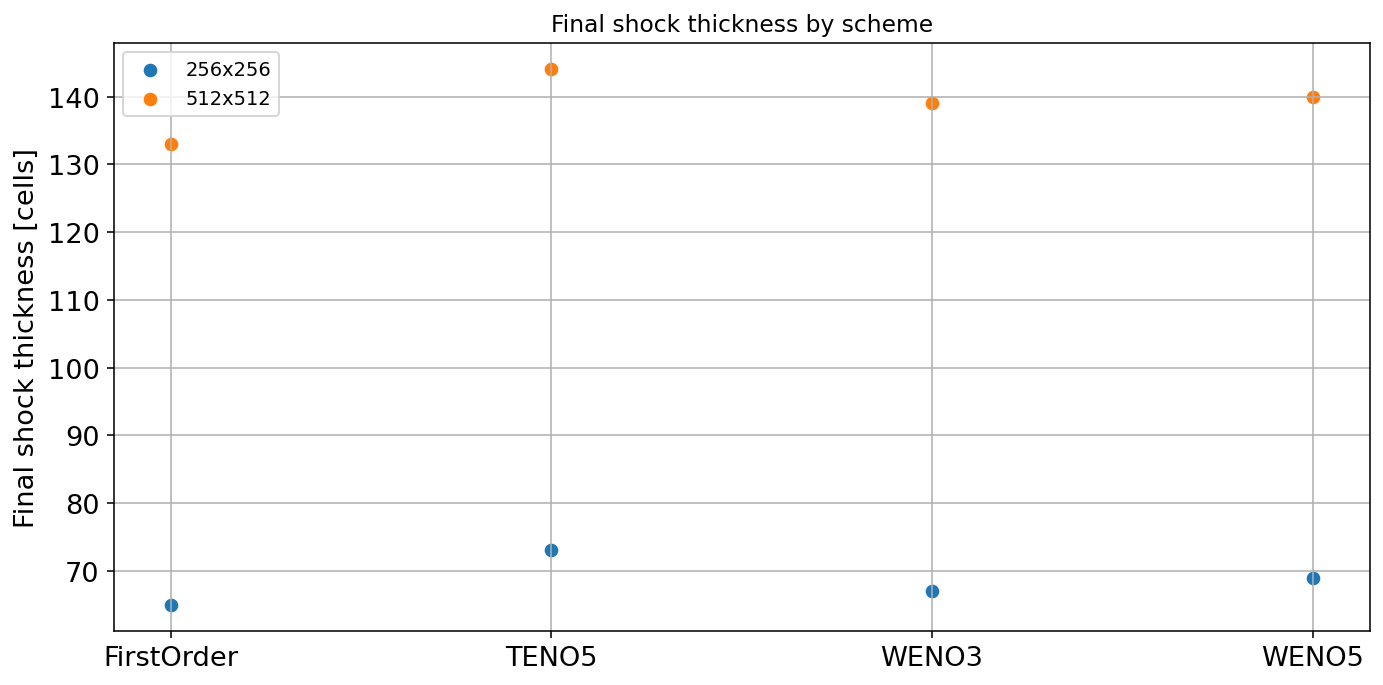

In [17]:
plot_df = df_final.sort_values(["nx", "scheme"])

plt.figure(figsize=(10, 5))
for nx, g in plot_df.groupby("nx"):
    plt.scatter(g["scheme"], g["thickness_cells"], marker="o", label=f"{nx}x{nx}")

plt.ylabel("Final shock thickness [cells]")
plt.title("Final shock thickness by scheme")
plt.legend()
plt.tight_layout()
plt.show()

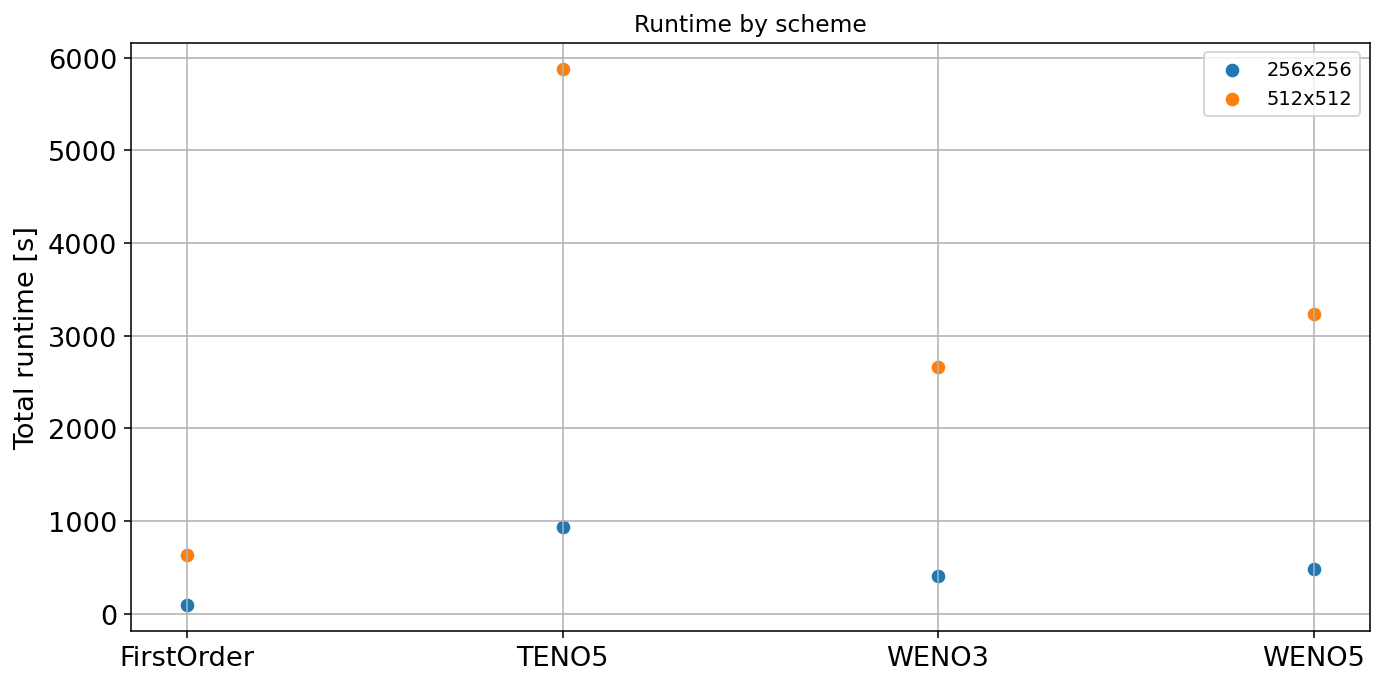

In [18]:
plt.figure(figsize=(10, 5))
for nx, g in plot_df.groupby("nx"):
    plt.scatter(g["scheme"], g["wall_total_s"], marker="o", label=f"{nx}x{nx}")

plt.ylabel("Total runtime [s]")
plt.title("Runtime by scheme")
plt.legend()
plt.tight_layout()
plt.show()

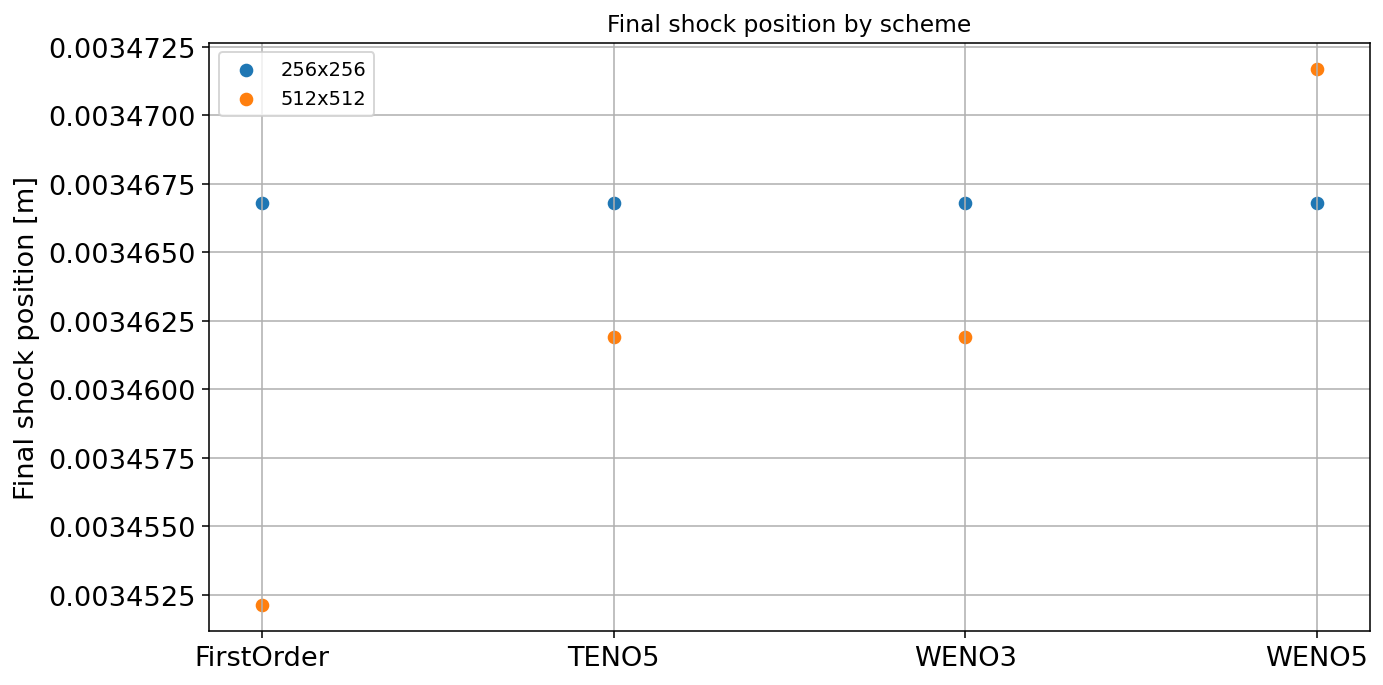

In [19]:
plt.figure(figsize=(10, 5))
for nx, g in plot_df.groupby("nx"):
    plt.scatter(g["scheme"], g["shock_x"], marker="o", label=f"{nx}x{nx}")

plt.ylabel("Final shock position [m]")
plt.title("Final shock position by scheme")
plt.legend()
plt.tight_layout()
plt.show()

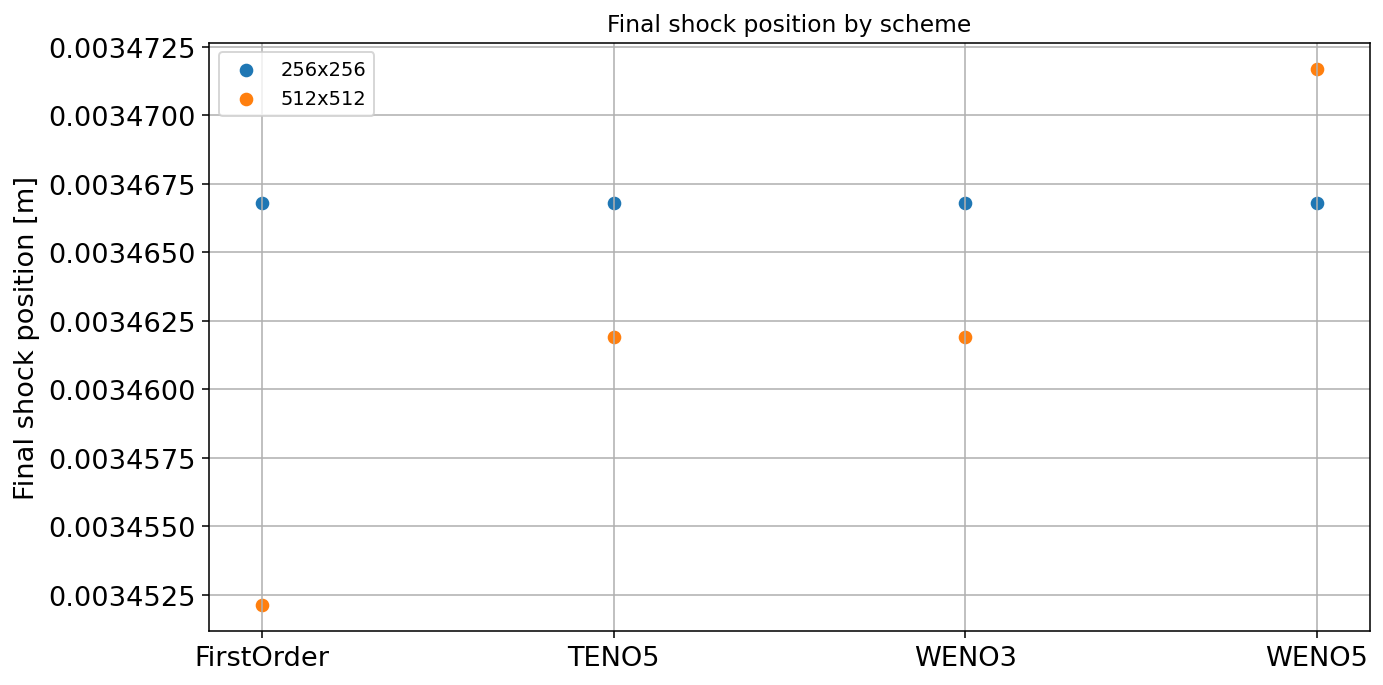

In [20]:
plt.figure(figsize=(10, 5))
for nx, g in plot_df.groupby("nx"):
    plt.scatter(g["scheme"], g["shock_x"], marker="o", label=f"{nx}x{nx}")

plt.ylabel("Final shock position [m]")
plt.title("Final shock position by scheme")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
with pd.ExcelWriter("diagnostics_analysis.xlsx") as writer:
    df_all.to_excel(writer, sheet_name="all_data", index=False)
    df_final.to_excel(writer, sheet_name="final_rows", index=False)
    summary_table.to_excel(writer, sheet_name="summary_table", index=False)

    if "df_vs_ref" in globals() and not df_vs_ref.empty:
        df_vs_ref.to_excel(writer, sheet_name="vs_reference", index=False)

print("Saved diagnostics_analysis.xlsx")

Saved diagnostics_analysis.xlsx
